In [1]:
import os
import torch
import timm
from PIL import Image
from torchvision import transforms
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

DATA_DIR = "Balanced_1500"

MODEL_PATHS = {
    "EfficientNet": "Models/efficientnet_model.pth",
    "ConvNeXt": "Models/convnext_model.pth",
    "Swin": "Models/swin_model.pth"
}

IMG_SIZE = 224
IMAGE_PATH = "Sample/Apple.jpg"

QUALITY_CLASSES = ["good", "bad", "mixed"]
FRUIT_CLASSES = sorted(os.listdir(DATA_DIR))

ENTROPY_THRESHOLD = 2.2
QUALITY_THRESHOLD = 0.35
MIN_CONFIDENCE = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("Fruit Classes:", FRUIT_CLASSES)

Using device: cuda
Fruit Classes: ['Apple', 'Banana', 'Grape', 'Guava', 'Lime', 'Mango', 'Orange', 'Pomegranate']


In [2]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

In [3]:
class MultiTaskModel(nn.Module):
    def __init__(self, backbone_name):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=False,
            num_classes=0
        )

        feat_dim = self.backbone.num_features

        self.fruit_head = nn.Sequential(
            nn.BatchNorm1d(feat_dim),
            nn.Dropout(0.4),
            nn.Linear(feat_dim, len(FRUIT_CLASSES))
        )

        self.quality_head = nn.Sequential(
            nn.BatchNorm1d(feat_dim),
            nn.Dropout(0.4),
            nn.Linear(feat_dim, len(QUALITY_CLASSES))
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.fruit_head(features), self.quality_head(features)

In [4]:
models = {
    "EfficientNet": MultiTaskModel("efficientnet_b0"),
    "ConvNeXt": MultiTaskModel("convnext_tiny"),
    "Swin": MultiTaskModel("swin_tiny_patch4_window7_224")
}

for name in models:
    models[name].load_state_dict(torch.load(MODEL_PATHS[name], map_location=device))
    models[name].to(device)
    models[name].eval()

print("All models loaded")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_9860\2378237657.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models[name].load_state_dict(torch.load(MODEL_PATHS[name], m

All models loaded


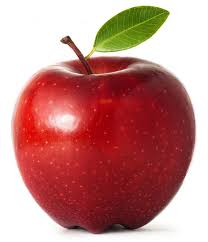

In [5]:
image = Image.open(IMAGE_PATH).convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(device)

display(image)

In [6]:
def predict(model, image_tensor):
    import time

    start = time.time()

    with torch.no_grad():
        fruit_logits, quality_logits = model(image_tensor)

        fruit_probs = torch.softmax(fruit_logits, dim=1)
        quality_probs = torch.softmax(quality_logits, dim=1)

        probs = fruit_probs[0]

        entropy = -torch.sum(probs * torch.log(probs + 1e-10)).item()
        top1_prob, top1_idx = torch.max(probs, 0)

        fruit_label = FRUIT_CLASSES[top1_idx.item()]

        quality_prob, quality_idx = torch.max(quality_probs, 1)
        quality_label = QUALITY_CLASSES[quality_idx.item()]

    end = time.time()

    return {
        "fruit": fruit_label,
        "fruit_conf": round(top1_prob.item() * 100, 2),   
        "quality": quality_label,
        "quality_conf": round(quality_prob.item() * 100, 2),  
        "entropy": round(entropy, 4),
        "time_taken": round(end - start, 4) 
    }

In [7]:
results = {}

print("\nIndividual Predictions:\n")

for name, model in models.items():
    res = predict(model, image_tensor)
    results[name] = res

    print(f"{name}")
    print(f"Fruit   → {res['fruit']}")
    print(f"Conf    → {res['fruit_conf']:.3f}")
    print(f"Quality → {res['quality']}")
    print(f"Entropy → {res['entropy']:.3f}")
    print("-" * 30)


Individual Predictions:

EfficientNet
Fruit   → Apple
Conf    → 50.100
Quality → good
Entropy → 1.488
------------------------------
ConvNeXt
Fruit   → Apple
Conf    → 63.580
Quality → good
Entropy → 1.353
------------------------------
Swin
Fruit   → Apple
Conf    → 47.660
Quality → good
Entropy → 1.678
------------------------------


In [8]:
def ensemble_predict(models, image_tensor):
    import time

    start = time.time()

    fruit_probs_list = []
    quality_probs_list = []

    best_model_name = None
    best_conf = 0

    with torch.no_grad():
        for name, model in models.items():
            fruit_logits, quality_logits = model(image_tensor)

            fruit_probs = torch.softmax(fruit_logits, dim=1)
            quality_probs = torch.softmax(quality_logits, dim=1)

            fruit_probs_list.append(fruit_probs)
            quality_probs_list.append(quality_probs)

            f_conf = torch.max(fruit_probs[0]).item()
            q_conf = torch.max(quality_probs[0]).item()
            combined_conf = (f_conf + q_conf) / 2

            if combined_conf > best_conf:
                best_conf = combined_conf
                best_model_name = name

    avg_fruit_probs = torch.mean(torch.stack(fruit_probs_list), dim=0)
    avg_quality_probs = torch.mean(torch.stack(quality_probs_list), dim=0)

    probs = avg_fruit_probs[0]

    entropy = -torch.sum(probs * torch.log(probs + 1e-10)).item()

    top1_prob, top1_idx = torch.max(probs, 0)
    fruit_label = FRUIT_CLASSES[top1_idx.item()]

    quality_prob, quality_idx = torch.max(avg_quality_probs, 1)
    quality_label = QUALITY_CLASSES[quality_idx.item()]

    end = time.time()

    return {
        "fruit": fruit_label,
        "fruit_conf": round(top1_prob.item() * 100, 2),
        "quality": quality_label,
        "quality_conf": round(quality_prob.item() * 100, 2),
        "entropy": round(entropy, 4),
        "time_taken": round(end - start, 4),
        "best_model": best_model_name
    }

In [9]:
ensemble_result = ensemble_predict(models, image_tensor)

print("\n Ensemble Prediction:")
print(f"Fruit   → {ensemble_result['fruit']}")
print(f"F Conf    → {ensemble_result['fruit_conf']:.2f}%")
print(f"Quality → {ensemble_result['quality']}")
print(f"Q Conf  → {ensemble_result['quality_conf']:.2f}%")
print(f"Entropy → {ensemble_result['entropy']:.4f}")
print(f"Time    → {ensemble_result['time_taken']:.4f} sec")
print(f"Best Model → {ensemble_result.get('best_model', 'Not Available')}")


 Ensemble Prediction:
Fruit   → Apple
F Conf    → 53.78%
Quality → good
Q Conf  → 76.51%
Entropy → 1.5531
Time    → 0.1170 sec
Best Model → ConvNeXt


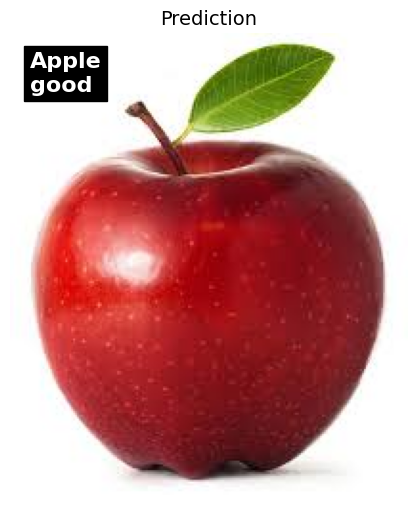

In [10]:
import matplotlib.pyplot as plt

unique_preds = set([res["fruit"] for res in results.values()])
disagreement = len(unique_preds) > 1

if (ensemble_result["entropy"] > ENTROPY_THRESHOLD) or \
   (ensemble_result["fruit_conf"] < MIN_CONFIDENCE) or \
   disagreement:

    final_fruit = "Unknown Fruit"
else:
    final_fruit = ensemble_result["fruit"]

final_quality = ensemble_result["quality"]

plt.figure(figsize=(6,6))

plt.imshow(image)
plt.axis("off")

plt.text(
    10, 30,
    f"{final_fruit}\n{final_quality}",
    color="white",
    fontsize=16,
    fontweight="bold",
    backgroundcolor="black"
)

plt.title("Prediction", fontsize=14)

plt.show()

In [11]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

DATA_DIR = "Balanced_1500"
BATCH_SIZE = 128
USE_SUBSET = True
SUBSET_SIZE = 500

dataset_full = ImageFolder(DATA_DIR, transform=transform)

if USE_SUBSET:
    dataset = Subset(dataset_full, range(min(SUBSET_SIZE, len(dataset_full))))
    print(f"Using subset: {len(dataset)} images")
else:
    dataset = dataset_full
    print(f"Using full dataset: {len(dataset)} images")

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Loader created successfully")

Using subset: 500 images
Loader created successfully


In [12]:
import torch

def evaluate_accuracy(model, loader, device):
    model.eval()

    correct = 0
    total = 0

    confident_correct = 0
    confident_total = 0

    total_entropy = 0
    total_conf = 0
    count = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits, _ = model(images)

            probs = torch.softmax(logits, dim=1)

            preds = torch.argmax(probs, dim=1)

            confidences = torch.max(probs, dim=1).values

            entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            total_entropy += entropy.sum().item()
            total_conf += confidences.sum().item()
            count += len(images)

            mask = (entropy <= ENTROPY_THRESHOLD) & (confidences >= MIN_CONFIDENCE)

            filtered_preds = preds[mask]
            filtered_labels = labels[mask]

            confident_total += filtered_labels.size(0)
            confident_correct += (filtered_preds == filtered_labels).sum().item()

    normal_acc = correct / total if total > 0 else 0

    filtered_acc = (
        confident_correct / confident_total
        if confident_total > 0 else 0
    )

    coverage = confident_total / total if total > 0 else 0

    avg_entropy = total_entropy / count if count > 0 else 0
    avg_confidence = total_conf / count if count > 0 else 0

    return {
        "normal_acc": normal_acc,
        "filtered_acc": filtered_acc,
        "coverage": coverage,
        "avg_entropy": avg_entropy,
        "avg_conf": avg_confidence
    }

print("\n Improved Accuracy Results:\n")

for name, model in models.items():
    results = evaluate_accuracy(model, loader, device)

    print(f" {name}")
    print(f"Normal Accuracy        → {results['normal_acc']:.4f}")
    print(f"Filtered Accuracy     → {results['filtered_acc']:.4f}")
    print(f"Coverage              → {results['coverage']:.2%}")
    print(f"Avg Entropy           → {results['avg_entropy']:.4f}")
    print(f"Avg Confidence        → {results['avg_conf']:.4f}")
    print("-" * 50)


 Improved Accuracy Results:

 EfficientNet
Normal Accuracy        → 0.9680
Filtered Accuracy     → 1.0000
Coverage              → 87.00%
Avg Entropy           → 1.1039
Avg Confidence        → 0.6880
--------------------------------------------------
 ConvNeXt
Normal Accuracy        → 0.9500
Filtered Accuracy     → 0.9953
Coverage              → 86.00%
Avg Entropy           → 1.1522
Avg Confidence        → 0.6775
--------------------------------------------------
 Swin
Normal Accuracy        → 0.9880
Filtered Accuracy     → 0.9979
Coverage              → 94.80%
Avg Entropy           → 1.0265
Avg Confidence        → 0.7312
--------------------------------------------------


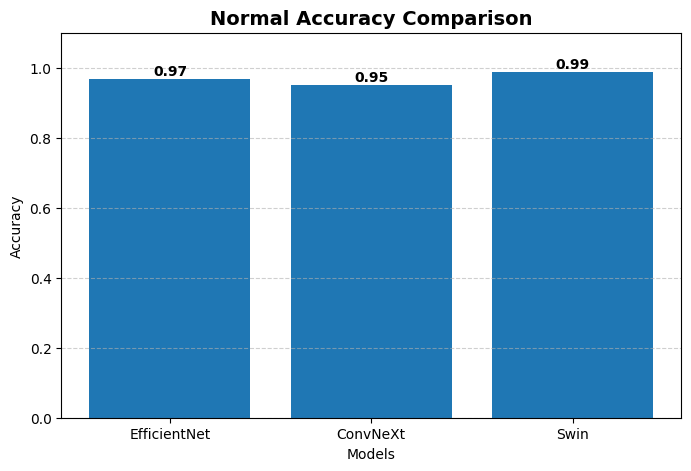

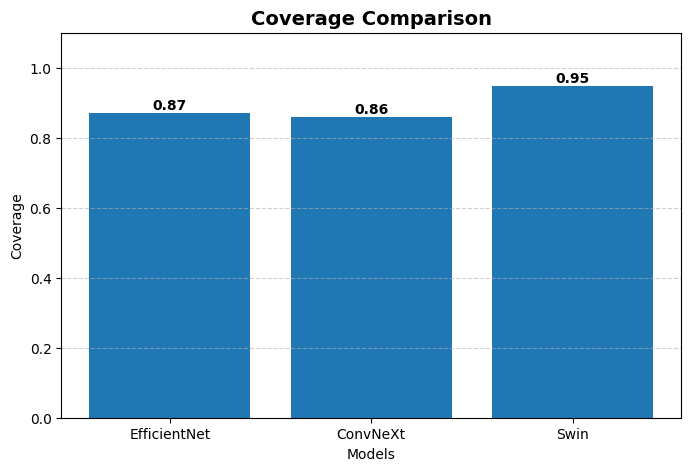

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ================= COLLECT RESULTS =================
model_names = []
normal_acc = []
coverage = []

for name, model in models.items():
    metrics = evaluate_accuracy(model, loader, device)

    model_names.append(name)
    normal_acc.append(metrics["normal_acc"])
    coverage.append(metrics["coverage"])

x = np.arange(len(model_names))

plt.figure(figsize=(8,5))

plt.bar(x, normal_acc)

for i, v in enumerate(normal_acc):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

plt.xticks(x, model_names)
plt.ylim(0, 1.1)
plt.title("Normal Accuracy Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

plt.figure(figsize=(8,5))

plt.bar(x, coverage)

for i, v in enumerate(coverage):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

plt.xticks(x, model_names)
plt.ylim(0, 1.1)
plt.title("Coverage Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Models")
plt.ylabel("Coverage")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()